In [23]:
# Cell 1 — Import libraries

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
# Cell 2 — Set data folder path

DATA_DIR = "/content/data_sources"

print("Current files in data folder:")
for file in os.listdir(DATA_DIR):
    print(file)

Current files in data folder:
data_dictionary.csv
schedule_2_goods_2023.csv
schedule_2_countries_2023.csv
schedule_2_details_2023.csv
new_ongoing_programs_2023_updated.csv
financial_section_a_b_and_c_2023.csv
schedule_2_resources_2023_0721.csv


In [25]:
# Cell 3 — Helper function to load CSV files safely

def read_csv_safely(file_name):
    path = os.path.join(DATA_DIR, file_name)

    try:
        return pd.read_csv(path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="ISO-8859-1", low_memory=False)

details = read_csv_safely("schedule_2_details_2023.csv")
resources = read_csv_safely("schedule_2_resources_2023_0721.csv")
countries = read_csv_safely("schedule_2_countries_2023.csv")
goods = read_csv_safely("schedule_2_goods_2023.csv")
financial = read_csv_safely("financial_section_a_b_and_c_2023.csv")
programs = read_csv_safely("new_ongoing_programs_2023_updated.csv")

print("Files loaded successfully.")

Files loaded successfully.


In [26]:
# Cell 4 — Standardize column names by trimming spaces

datasets = {
    "details": details,
    "resources": resources,
    "countries": countries,
    "goods": goods,
    "financial": financial,
    "programs": programs
}

for name, df in datasets.items():
    df.columns = df.columns.astype(str).str.strip()
    print(f"{name}: {df.shape}")
    print(df.columns.tolist())
    print("-" * 80)

details: (5047, 10)
['BN', 'FPE', 'Form ID', '200', '210', '220', '230', '240', '250', '260']
--------------------------------------------------------------------------------
resources: (15321, 7)
['BN', 'FPE', 'Form ID', '#', 'Indiv/Org Name', 'Amount', 'Country']
--------------------------------------------------------------------------------
countries: (9304, 5)
['BN', 'FPE', 'Form ID', '#', 'Country']
--------------------------------------------------------------------------------
goods: (913, 8)
['BN', 'FPE', 'Form ID', '#', 'Item Name', 'Item Value', 'Destination', 'Country']
--------------------------------------------------------------------------------
financial: (84155, 70)
['BN', 'FPE', 'Form ID', 'Program #1 Code', 'Program #1 %', 'Program #1 Desc', 'Program #2 Code', 'Program #2 %', 'Program #2 Desc', 'Program #3 Code', 'Program #3 %', 'Program #3 Desc', '1510', '1510-BN', '1510-Name', '1570', '1600', '1800', '2000', '2100', '2400', '5030', '5031', '5032', '2500', '2510', 

In [27]:
# Cell 5 — Initial preview of each dataset

display(details.head())
display(resources.head())
display(countries.head())
display(goods.head())
display(financial.head())
display(programs.head())

,BN,FPE,Form ID,200,210,220,230,240,250,260
0,851888412RR0001,2023-02-14,25,24224.0,N,N,NaN,N,Y,Y
1,849677091RR0001,2023-02-28,25,3500.0,Y,N,NaN,N,N,N
2,807954623RR0001,2023-02-28,25,12416.0,N,N,NaN,N,Y,N
3,810530550RR0001,2023-02-28,25,250.0,N,N,NaN,N,Y,N
4,730087921RR0001,2023-02-02,25,54487.0,Y,N,NaN,N,Y,N


,BN,FPE,Form ID,#,Indiv/Org Name,Amount,Country
0,849677091RR0001,2023-02-28,25,1,Dr. Gilliam Saloojee Teenager and Bophelo Day ...,3500.0,ZA
1,730087921RR0001,2023-02-02,25,1,Shree Swaminarayan Gurukul Sarvajiv Hitavah Trust,11571.0,IN
2,850144502RR0001,2023-01-31,25,1,Wings of Hope for Africa Association,8150.0,BI
3,701554891RR0001,2023-03-31,25,1,"Lighthouse Missions Ministry Philippines, Inc.",16700.0,PH
4,822816237RR0001,2023-02-28,25,1,"Djeffly, Philocies",721.0,HT


,BN,FPE,Form ID,#,Country
0,851888412RR0001,2023-02-14,25,1,BI
1,849677091RR0001,2023-02-28,25,1,ZA
2,807954623RR0001,2023-02-28,25,1,PE
3,730087921RR0001,2023-02-02,25,1,IN
4,743036600RR0001,2023-03-31,25,1,UG


,BN,FPE,Form ID,#,Item Name,Item Value,Destination,Country
0,851888412RR0001,2023-02-14,25,1,ARTICLES DE SPORTS,0.0,"BUJUMBURA, NGAZI",BI
1,851888412RR0001,2023-02-14,25,2,VÊTEMENTS USAGÉS,0.0,"RUTANA, BURAMBI",BI
2,851888412RR0001,2023-02-14,25,3,JOUETS SOULIERS,0.0,"RUYIGI, GATUMBA",BI
3,701554891RR0001,2023-03-31,25,1,Non-perishables,0.0,"La Union, Abra, Ilocos Norte, Zambales, Palawa...",PH
4,717096671RR0001,2023-02-28,26,1,SCHOOL SUPPLIES,300.0,BULACAN,PH


,BN,FPE,Form ID,Program #1 Code,Program #1 %,Program #1 Desc,Program #2 Code,Program #2 %,Program #2 Desc,Program #3 Code,...,5840,5841,5842,5843,5850,5860,5861,5862,5863,5864
0,870814944RR0001,2023-01-31,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,713482297RR0001,2023-01-31,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,890765845RR0001,2023-01-31,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,747889004RR0001,2023-02-10,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,815258793RR0001,2023-01-31,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,BN,FPE,FormID,Program Type,Description
0,870814944RR0001,2023-01-31,25,OP,Activities and programs include: 1834 building...
1,870814944RR0001,2023-01-31,25,NP,Hope 225 community events; Indigenous exhibit;...
2,713482297RR0001,2023-01-31,25,OP,MEDICAL EQUIPMENT LENDING TO THOSE IN NEED. NO...
3,890765845RR0001,2023-01-31,25,OP,AWARDS A SCHOLARSHIP TO A SECOND YEAR ENGINEER...
4,747889004RR0001,2023-02-10,25,OP,Receive and maintain funds and apply all or pa...


In [28]:
# Cell 6 — Basic data quality summary

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Unique BN": df["BN"].nunique() if "BN" in df.columns else np.nan,
        "Missing Cells": df.isna().sum().sum(),
        "Missing Cell %": round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,Dataset,Rows,Columns,Unique BN,Missing Cells,Missing Cell %
0,details,5047,10,5041,6087,12.06
1,resources,15321,7,2801,1929,1.80
2,countries,9304,5,3531,11,0.02
3,goods,913,8,277,107,1.46
4,financial,84155,70,83983,4041235,68.60
5,programs,95570,5,81340,4485,0.94


In [29]:
# Cell 7 — Convert date fields and numeric fields

for df in [details, resources, countries, goods, financial, programs]:
    if "FPE" in df.columns:
        df["FPE"] = pd.to_datetime(df["FPE"], errors="coerce")

# Convert main amount fields
if "200" in details.columns:
    details["200"] = pd.to_numeric(details["200"], errors="coerce")

if "Amount" in resources.columns:
    resources["Amount"] = pd.to_numeric(resources["Amount"], errors="coerce")

if "Item Value" in goods.columns:
    goods["Item Value"] = pd.to_numeric(goods["Item Value"], errors="coerce")

print("Date and numeric conversion completed.")

Date and numeric conversion completed.


In [30]:
# Cell 8 — Standardize country fields

def clean_country_column(df, col="Country"):
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .replace({
                "NAN": np.nan,
                "NONE": np.nan,
                "NULL": np.nan,
                "": np.nan
            })
        )

clean_country_column(resources)
clean_country_column(countries)
clean_country_column(goods)

print("Country fields standardized.")

Country fields standardized.


In [31]:
# Cell 9 — Standardize Y/N flag fields in Schedule 2 details

flag_cols = ["210", "220", "230", "240", "250", "260"]
existing_flag_cols = [col for col in flag_cols if col in details.columns]

for col in existing_flag_cols:
    details[col] = (
        details[col]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({
            "NAN": np.nan,
            "NONE": np.nan,
            "NULL": np.nan,
            "": np.nan
        })
    )

print("Existing flag columns:", existing_flag_cols)

for col in existing_flag_cols:
    print(f"\nFrequency table for {col}:")
    display(details[col].value_counts(dropna=False))

Existing flag columns: ['210', '220', '230', '240', '250', '260']

Frequency table for 210:


,count
210,
Y,2849
N,2138
NaN,60



Frequency table for 220:


,count
220,
N,4780
Y,141
NaN,126



Frequency table for 230:


...

,count
240,
N,3782
Y,1132
NaN,133



Frequency table for 250:


,count
250,
N,2771
Y,2151
NaN,125



Frequency table for 260:


,count
260,
N,4613
Y,281
NaN,153


In [32]:
# Cell 10 — Missing value summary for each selected dataset

for name, df in datasets.items():
    print(f"\nMissing value summary: {name}")
    missing_summary = pd.DataFrame({
        "Missing Count": df.isna().sum(),
        "Missing %": (df.isna().mean() * 100).round(2)
    }).sort_values("Missing %", ascending=False)

    display(missing_summary.head(15))


Missing value summary: details


,Missing Count,Missing %
230,4917,97.42
200,573,11.35
260,153,3.03
240,133,2.64
220,126,2.50
250,125,2.48
210,60,1.19
BN,0,0.00
FPE,0,0.00
Form ID,0,0.00



Missing value summary: resources


,Missing Count,Missing %
Country,1075,7.02
Indiv/Org Name,702,4.58
Amount,152,0.99
Form ID,0,0.00
FPE,0,0.00
BN,0,0.00
#,0,0.00



Missing value summary: countries


...

,Missing Count,Missing %
Destination,45,4.93
Item Value,38,4.16
Country,15,1.64
Item Name,9,0.99
#,0,0.00
Form ID,0,0.00
FPE,0,0.00
BN,0,0.00



Missing value summary: financial


,Missing Count,Missing %
5031,84155,100.00
5030,84155,100.00
2740,84153,100.00
5032,84155,100.00
2750,84134,99.98
2770,84111,99.95
Program #3 Desc,84091,99.92
Program #2 Desc,84089,99.92
Program #1 Desc,84061,99.89
2790,83903,99.70



Missing value summary: programs


,Missing Count,Missing %
Program Type,3131,3.28
Description,1354,1.42
BN,0,0.00
FormID,0,0.00
FPE,0,0.00


,Amount
count,1.516900e+04
mean,2.563558e+05
std,2.070541e+06
min,-1.500000e+05
25%,4.832000e+03
50%,1.938400e+04
75%,7.500000e+04
max,1.585668e+08


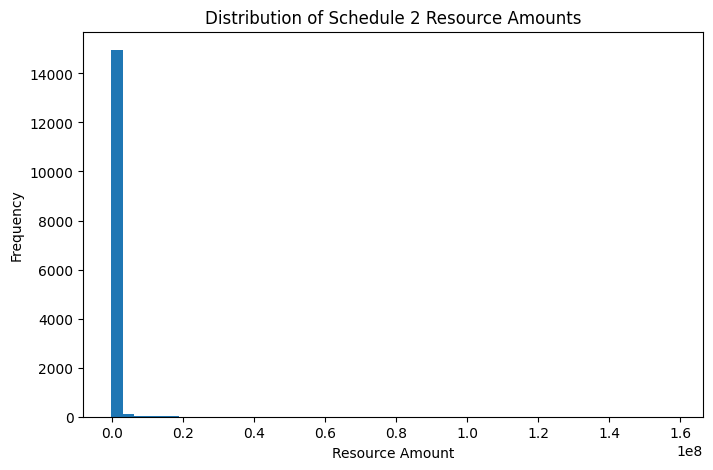

In [33]:
# Cell 11 — EDA: Resource amount distribution

display(resources["Amount"].describe())

plt.figure(figsize=(8, 5))
plt.hist(resources["Amount"].dropna(), bins=50)
plt.title("Distribution of Schedule 2 Resource Amounts")
plt.xlabel("Resource Amount")
plt.ylabel("Frequency")
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


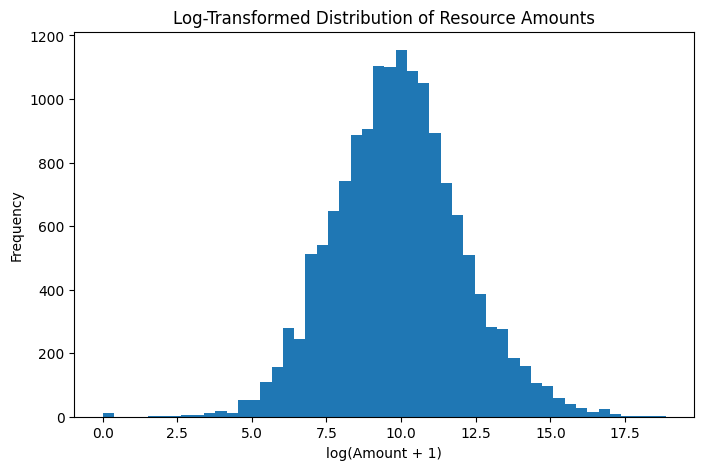

In [34]:
# Cell 12 — EDA: Log-transformed resource amount distribution

resources["Log_Amount"] = np.log1p(resources["Amount"])

plt.figure(figsize=(8, 5))
plt.hist(resources["Log_Amount"].dropna(), bins=50)
plt.title("Log-Transformed Distribution of Resource Amounts")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

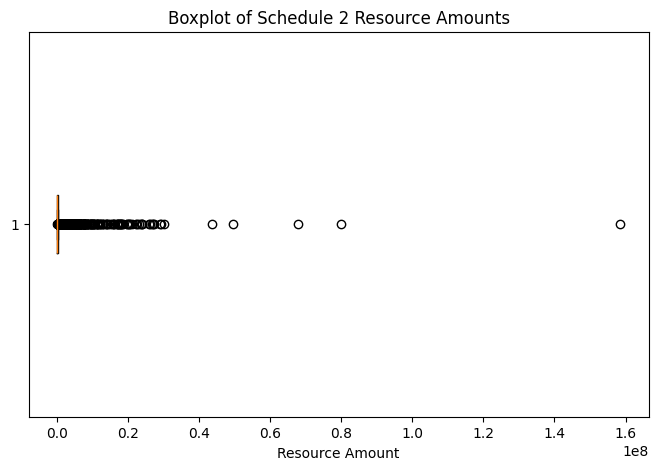

In [35]:
# Cell 13 — EDA: Boxplot for resource amount outliers

plt.figure(figsize=(8, 5))
plt.boxplot(resources["Amount"].dropna(), vert=False)
plt.title("Boxplot of Schedule 2 Resource Amounts")
plt.xlabel("Resource Amount")
plt.show()

In [36]:
# Cell 14 — Outlier detection using IQR method

q1 = resources["Amount"].quantile(0.25)
q3 = resources["Amount"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

resource_outliers = resources[
    (resources["Amount"] < lower_bound) |
    (resources["Amount"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of potential outliers:", resource_outliers.shape[0])

display(resource_outliers.sort_values("Amount", ascending=False).head(10))

Q1: 4832.0
Q3: 75000.0
IQR: 70168.0
Lower bound: -100420.0
Upper bound: 180252.0
Number of potential outliers: 2158


,BN,FPE,Form ID,#,Indiv/Org Name,Amount,Country,Log_Amount
510,107511586RR0001,2023-03-31,26,1,Please see attachment A,158566763.0,NaN,18.881686
1439,119219814RR0001,2023-03-31,26,57,International Federation of Red Cross & Red Cr...,80000000.0,UA,18.197537
12863,817387277RR0001,2023-12-31,27,82,AFRICAN LEADERSHIP UNIVERSITY FOUNDATION,67895000.0,KE,18.033473
5769,119304855RR0001,2023-09-30,26,51,WORLD VISION INTERNATIONAL,49341126.0,SS,17.714269
5768,119304855RR0001,2023-09-30,26,50,WORLD VISION INTERNATIONAL,43641727.0,SO,17.591524
5773,119304855RR0001,2023-09-30,26,55,WORLD VISION INTERNATIONAL,30012114.0,US,17.217112
6129,100072586RR0001,2023-12-31,27,1,Aga Khan Foundation,29164044.0,NaN,17.188447
3474,118928993RR0001,2023-06-30,26,8,NaN,28949826.0,CM,17.181075
13023,817387277RR0001,2023-12-31,27,242,GHANA ENTERPRISES AGENCY (FORMERLY NBSSSI),27296326.0,GH,17.122263
5757,119304855RR0001,2023-09-30,26,39,WORLD VISION INTERNATIONAL,26948428.0,ML,17.109436


,Amount
Country,
KE,290931616.0
IL,280009614.0
US,234685920.0
ET,224705639.0
QS,214896295.0
GH,204982561.0
UG,177713186.0
UA,154422280.0
NG,112660270.0


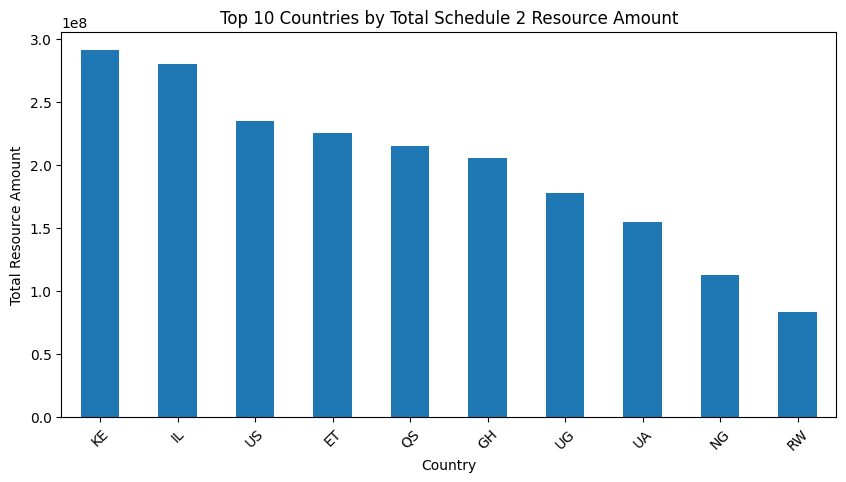

In [37]:
# Cell 15 — Top 10 countries by total resource amount

country_amounts = (
    resources
    .dropna(subset=["Country"])
    .groupby("Country")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(country_amounts)

plt.figure(figsize=(10, 5))
country_amounts.plot(kind="bar")
plt.title("Top 10 Countries by Total Schedule 2 Resource Amount")
plt.xlabel("Country")
plt.ylabel("Total Resource Amount")
plt.xticks(rotation=45)
plt.show()

,0
Country,
US,1626
IL,857
IN,826
KE,680
QS,583
UG,465
QR,379
PH,369
HT,340


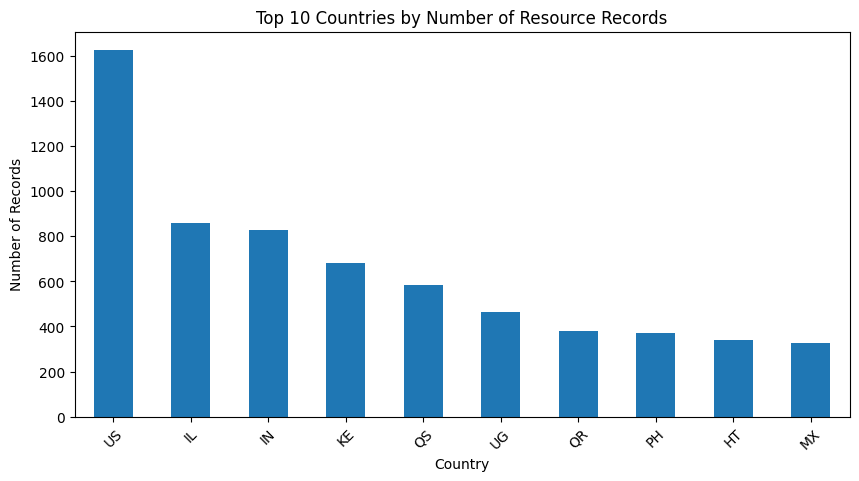

In [38]:
# Cell 16 — Top 10 countries by number of resource records

country_counts = (
    resources
    .dropna(subset=["Country"])
    .groupby("Country")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

display(country_counts)

plt.figure(figsize=(10, 5))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Number of Resource Records")
plt.xlabel("Country")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [39]:
# Cell 17 — Aggregate Schedule 2 resources by BN

resources_by_bn = (
    resources
    .groupby("BN", as_index=False)
    .agg(
        Total_Resource_Amount=("Amount", "sum"),
        Resource_Record_Count=("Amount", "count"),
        Resource_Country_Count=("Country", "nunique")
    )
)

display(resources_by_bn.head())
print("Aggregated resource table shape:", resources_by_bn.shape)

,BN,Total_Resource_Amount,Resource_Record_Count,Resource_Country_Count
0,100072586RR0001,31121933.0,3,0
1,100193457RR0001,53835.0,1,1
2,100764638RR0001,675000.0,1,1
3,100764646RR0001,93716.0,1,1
4,103066064RR0001,989210.0,1,2


Aggregated resource table shape: (2801, 4)


In [40]:
# Cell 18 — Aggregate Schedule 2 countries by BN

countries_by_bn = (
    countries
    .groupby("BN", as_index=False)
    .agg(
        Schedule2_Country_Count=("Country", "nunique"),
        Schedule2_Country_Record_Count=("Country", "count")
    )
)

display(countries_by_bn.head())
print("Aggregated country table shape:", countries_by_bn.shape)

,BN,Schedule2_Country_Count,Schedule2_Country_Record_Count
0,100072586RR0001,11,11
1,100764638RR0001,1,1
2,100766427RR0001,2,2
3,101144541RR0001,1,1
4,102992047RR0001,1,1


Aggregated country table shape: (3531, 3)


,Item Value
count,8.750000e+02
mean,1.962247e+05
std,1.009575e+06
min,0.000000e+00
25%,1.000000e+03
50%,4.513000e+03
75%,4.133400e+04
max,2.027677e+07


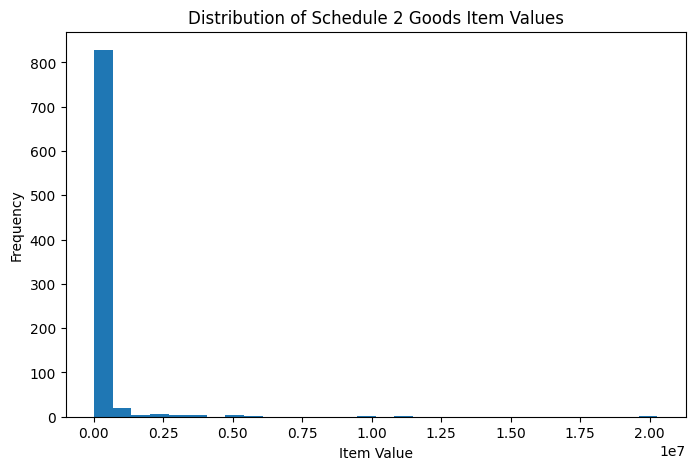

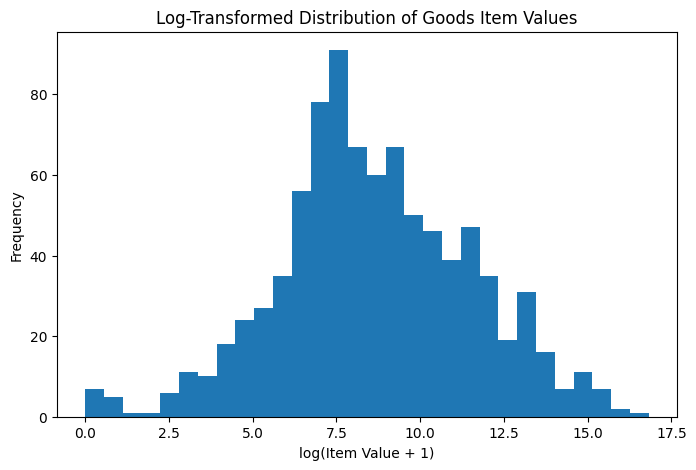

In [41]:
# Cell 19 — EDA: Goods / in-kind resource values

if "Item Value" in goods.columns:
    display(goods["Item Value"].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(goods["Item Value"].dropna(), bins=30)
    plt.title("Distribution of Schedule 2 Goods Item Values")
    plt.xlabel("Item Value")
    plt.ylabel("Frequency")
    plt.show()

    goods["Log_Item_Value"] = np.log1p(goods["Item Value"])

    plt.figure(figsize=(8, 5))
    plt.hist(goods["Log_Item_Value"].dropna(), bins=30)
    plt.title("Log-Transformed Distribution of Goods Item Values")
    plt.xlabel("log(Item Value + 1)")
    plt.ylabel("Frequency")
    plt.show()

In [42]:
# Cell 20 — Aggregate Schedule 2 goods by BN

goods_by_bn = (
    goods
    .groupby("BN", as_index=False)
    .agg(
        Total_Goods_Value=("Item Value", "sum"),
        Goods_Record_Count=("Item Value", "count"),
        Goods_Country_Count=("Country", "nunique")
    )
)

display(goods_by_bn.head())
print("Aggregated goods table shape:", goods_by_bn.shape)

,BN,Total_Goods_Value,Goods_Record_Count,Goods_Country_Count
0,100072586RR0001,675.0,1,1
1,106735400RR0001,3821805.0,1,1
2,106792161RR0001,181102.0,5,2
3,106846942RR0001,25362.0,7,7
4,106863061RR0001,5774575.0,4,1


Aggregated goods table shape: (277, 4)


,count
Program Type,
OP,78167
NP,14272
NaN,3131


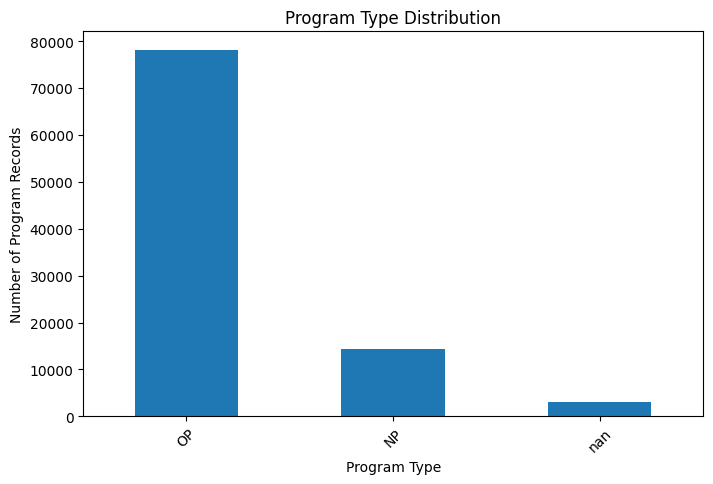

In [43]:
# Cell 21 — EDA: Program type distribution

if "Program Type" in programs.columns:
    program_type_counts = programs["Program Type"].value_counts(dropna=False)

    display(program_type_counts)

    plt.figure(figsize=(8, 5))
    program_type_counts.plot(kind="bar")
    plt.title("Program Type Distribution")
    plt.xlabel("Program Type")
    plt.ylabel("Number of Program Records")
    plt.xticks(rotation=45)
    plt.show()

In [44]:
# Cell 22 — Aggregate program data by BN

programs_by_bn = (
    programs
    .groupby("BN", as_index=False)
    .agg(
        Program_Record_Count=("Description", "count"),
        Program_Type_Count=("Program Type", "nunique")
    )
)

display(programs_by_bn.head())
print("Aggregated program table shape:", programs_by_bn.shape)

,BN,Program_Record_Count,Program_Type_Count
0,100021237RR0001,1,1
1,100021252RR0001,1,1
2,100040781RR0001,2,2
3,100042670RR0001,1,1
4,100044452RR0001,1,1


Aggregated program table shape: (81340, 3)


In [45]:
# Cell 23 — Prepare financial context table

# Because the financial file uses numbered fields without a confirmed codebook,
# this version only creates general integration metrics rather than interpreting specific fields.

financial_by_bn = (
    financial
    .groupby("BN", as_index=False)
    .agg(
        Financial_Record_Count=("BN", "count")
    )
)

display(financial_by_bn.head())
print("Aggregated financial table shape:", financial_by_bn.shape)

,BN,Financial_Record_Count
0,100021237RR0001,1
1,100021252RR0001,1
2,100040781RR0001,1
3,100042373RR0001,1
4,100042670RR0001,1


Aggregated financial table shape: (83983, 2)


In [46]:
# Cell 24 — Merge all prepared tables into one analysis dataset

merged = details.copy()

merged = merged.merge(resources_by_bn, on="BN", how="left")
merged = merged.merge(countries_by_bn, on="BN", how="left")
merged = merged.merge(goods_by_bn, on="BN", how="left")
merged = merged.merge(programs_by_bn, on="BN", how="left")
merged = merged.merge(financial_by_bn, on="BN", how="left")

print("Merged dataset shape:", merged.shape)
display(merged.head())

Merged dataset shape: (5047, 21)


,BN,FPE,Form ID,200,210,220,230,240,250,260,...,Resource_Record_Count,Resource_Country_Count,Schedule2_Country_Count,Schedule2_Country_Record_Count,Total_Goods_Value,Goods_Record_Count,Goods_Country_Count,Program_Record_Count,Program_Type_Count,Financial_Record_Count
0,851888412RR0001,2023-02-14,25,24224.0,N,N,NaN,N,Y,Y,...,NaN,NaN,1.0,1.0,0.0,3.0,1.0,1.0,1.0,1
1,849677091RR0001,2023-02-28,25,3500.0,Y,N,NaN,N,N,N,...,1.0,1.0,1.0,1.0,NaN,NaN,NaN,2.0,2.0,1
2,807954623RR0001,2023-02-28,25,12416.0,N,N,NaN,N,Y,N,...,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1
3,810530550RR0001,2023-02-28,25,250.0,N,N,NaN,N,Y,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,1
4,730087921RR0001,2023-02-02,25,54487.0,Y,N,NaN,N,Y,N,...,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1


,Missing Count,Missing %
230,4917,97.42
Goods_Record_Count,4769,94.49
Total_Goods_Value,4769,94.49
Goods_Country_Count,4769,94.49
Resource_Record_Count,2241,44.40
Total_Resource_Amount,2241,44.40
Resource_Country_Count,2241,44.40
Schedule2_Country_Count,1511,29.94
Schedule2_Country_Record_Count,1511,29.94
200,573,11.35


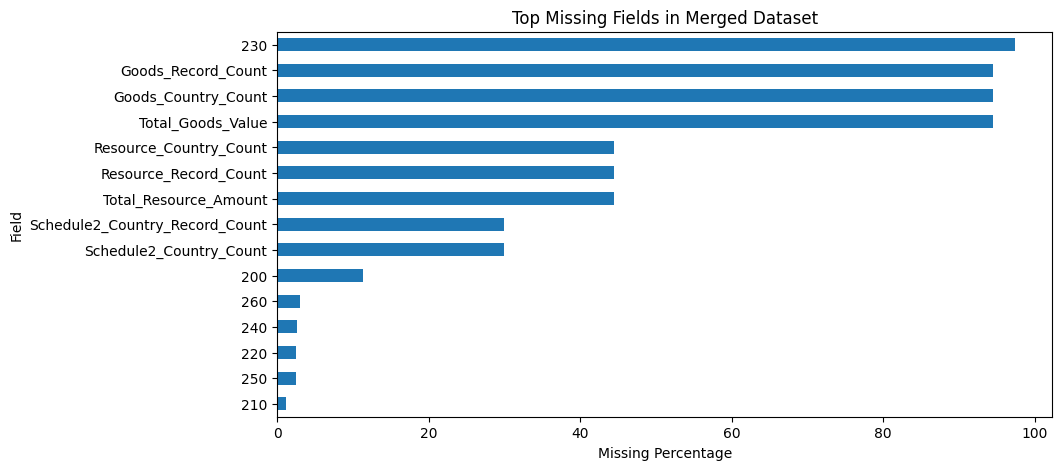

In [47]:
# Cell 25 — Missing values after integration

merged_missing = pd.DataFrame({
    "Missing Count": merged.isna().sum(),
    "Missing %": (merged.isna().mean() * 100).round(2)
}).sort_values("Missing %", ascending=False)

display(merged_missing.head(20))

plt.figure(figsize=(10, 5))
merged_missing["Missing %"].head(15).sort_values().plot(kind="barh")
plt.title("Top Missing Fields in Merged Dataset")
plt.xlabel("Missing Percentage")
plt.ylabel("Field")
plt.show()

,Integrated Source,Matched BN Count,Base Details BN Count,Coverage %
0,Resources,2806,5041,55.66
1,Countries,3536,5041,70.14
2,Goods,278,5041,5.51
3,Programs,4993,5041,99.05
4,Financial,5047,5041,100.12


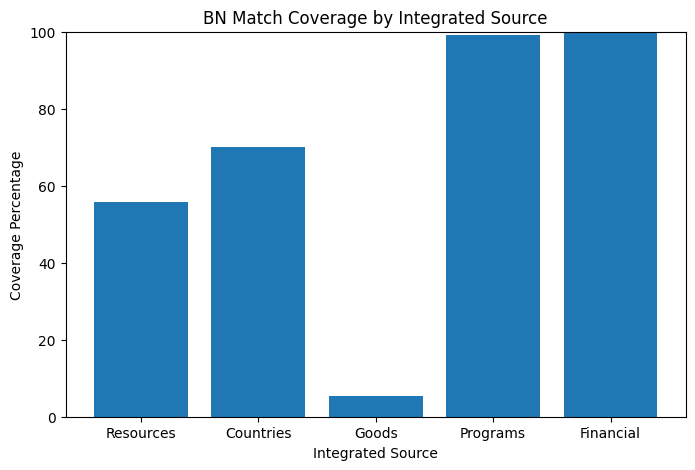

In [48]:
# Cell 26 — Integration coverage summary

coverage_summary = pd.DataFrame({
    "Integrated Source": [
        "Resources",
        "Countries",
        "Goods",
        "Programs",
        "Financial"
    ],
    "Matched BN Count": [
        merged["Total_Resource_Amount"].notna().sum(),
        merged["Schedule2_Country_Count"].notna().sum(),
        merged["Total_Goods_Value"].notna().sum(),
        merged["Program_Record_Count"].notna().sum(),
        merged["Financial_Record_Count"].notna().sum()
    ],
    "Base Details BN Count": [
        merged["BN"].nunique()
    ] * 5
})

coverage_summary["Coverage %"] = (
    coverage_summary["Matched BN Count"] / coverage_summary["Base Details BN Count"] * 100
).round(2)

display(coverage_summary)

plt.figure(figsize=(8, 5))
plt.bar(coverage_summary["Integrated Source"], coverage_summary["Coverage %"])
plt.title("BN Match Coverage by Integrated Source")
plt.xlabel("Integrated Source")
plt.ylabel("Coverage Percentage")
plt.ylim(0, 100)
plt.show()

,BN,200,Total_Resource_Amount,Amount_Difference
0,851888412RR0001,24224.0,NaN,NaN
1,849677091RR0001,3500.0,3500.0,0.0
2,807954623RR0001,12416.0,NaN,NaN
3,810530550RR0001,250.0,NaN,NaN
4,730087921RR0001,54487.0,11571.0,42916.0


,Amount_Difference
count,2.593000e+03
mean,2.081912e+05
std,1.824446e+06
min,-2.241925e+06
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,5.119787e+07


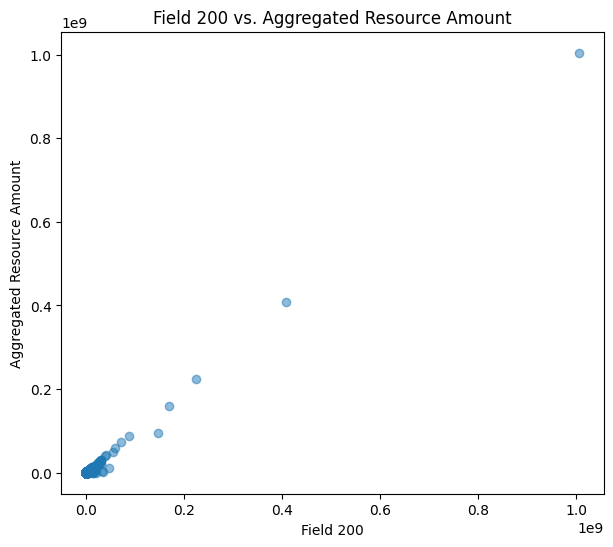

In [49]:
# Cell 27 — Compare reported total amount in field 200 with aggregated resource amount

if "200" in merged.columns:
    compare_amounts = merged[["BN", "200", "Total_Resource_Amount"]].copy()
    compare_amounts["Amount_Difference"] = compare_amounts["200"] - compare_amounts["Total_Resource_Amount"]

    display(compare_amounts.head())
    display(compare_amounts["Amount_Difference"].describe())

    plt.figure(figsize=(7, 6))
    plt.scatter(
        compare_amounts["200"],
        compare_amounts["Total_Resource_Amount"],
        alpha=0.5
    )
    plt.title("Field 200 vs. Aggregated Resource Amount")
    plt.xlabel("Field 200")
    plt.ylabel("Aggregated Resource Amount")
    plt.show()

,Schedule2_Country_Count,Resource_Country_Count
count,3536.000000,2806.000000
mean,2.633201,2.508197
std,3.933293,5.089478
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,3.000000,2.000000
max,85.000000,75.000000


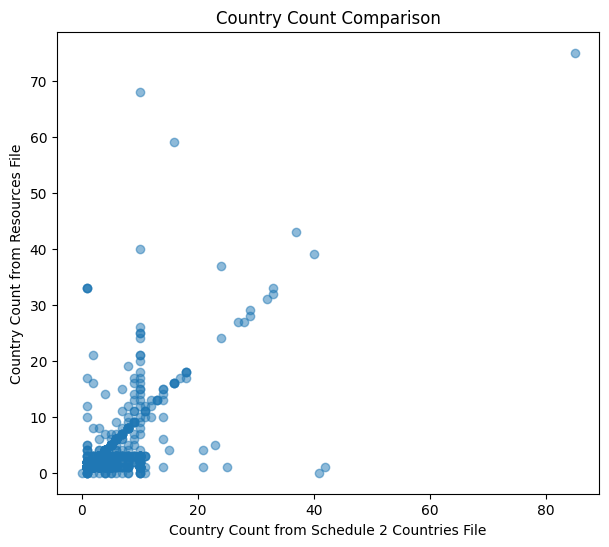

In [50]:
# Cell 28 — Country count comparison between countries table and resources table

country_compare = merged[
    ["BN", "Schedule2_Country_Count", "Resource_Country_Count"]
].copy()

display(country_compare.describe())

plt.figure(figsize=(7, 6))
plt.scatter(
    country_compare["Schedule2_Country_Count"],
    country_compare["Resource_Country_Count"],
    alpha=0.5
)
plt.title("Country Count Comparison")
plt.xlabel("Country Count from Schedule 2 Countries File")
plt.ylabel("Country Count from Resources File")
plt.show()

In [51]:
# Cell 29 — Final cleaned EDA summary table

eda_summary = pd.DataFrame({
    "Metric": [
        "Organizations in Schedule 2 details",
        "Resource records",
        "Countries in resources file",
        "Countries in countries file",
        "Goods records",
        "Program records",
        "Average resource amount",
        "Median resource amount",
        "Maximum resource amount",
        "Potential resource amount outliers",
        "Merged dataset rows",
        "Merged dataset columns"
    ],
    "Value": [
        details["BN"].nunique(),
        resources.shape[0],
        resources["Country"].nunique(),
        countries["Country"].nunique(),
        goods.shape[0],
        programs.shape[0],
        resources["Amount"].mean(),
        resources["Amount"].median(),
        resources["Amount"].max(),
        resource_outliers.shape[0],
        merged.shape[0],
        merged.shape[1]
    ]
})

display(eda_summary)

,Metric,Value
0,Organizations in Schedule 2 details,5.041000e+03
1,Resource records,1.532100e+04
2,Countries in resources file,1.870000e+02
3,Countries in countries file,1.980000e+02
4,Goods records,9.130000e+02
5,Program records,9.557000e+04
6,Average resource amount,2.563558e+05
7,Median resource amount,1.938400e+04
8,Maximum resource amount,1.585668e+08
9,Potential resource amount outliers,2.158000e+03
